In [1]:
import sys, pathlib
_here = pathlib.Path.cwd().resolve()
for _p in [_here, *_here.parents]:
    if (_p / "src" / "ml_textbook").exists():
        sys.path.insert(0, str(_p / "src"))
        break

# 01. 機械学習の全体像 — データから「汎化する」関数を作る

> この教材の読み方: 各章は **直感 → 最小限の数式 → scikit-learn 実装 → 可視化 → 実験 → 演習** の順で進みます。
> 本文は日本語、コードは英語、数式の中には日本語を入れません。

## この章で分かること

- 機械学習とは「データから関数 $f: X \to y$ を学び、**未知のデータでも当てる**」営みであること
- 教師あり(回帰・分類)/ 教師なし(クラスタリング)の違い
- **汎化** が目的であり、訓練データの精度は目的ではないこと
- **未学習 (underfitting)** と **過学習 (overfitting)**、その間にある **バイアス-バリアンスのトレードオフ**
- モデルの良し悪しは「複雑さ」だけでは決まらず、**正しく評価して初めて分かる**(→ 04 章)

機械学習を「賢い装置」ではなく、**損失を最小化してデータに合う関数を選ぶ最適化** として見ていきます。

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.io as pio

# This renderer keeps the plotly mimetype (so JupyterLab is interactive) and adds
# the JS shim that lets the sliders render in the exported Jupyter Book HTML too
# (the book loads require.js for exactly this). Same setup as the sibling books.
pio.renderers.default = "plotly_mimetype+notebook_connected"

from ml_textbook import datasets, plotting, models, metrics, widgets

RANDOM_SEED = 0
np.random.seed(RANDOM_SEED)
print("setup ok")

setup ok


## 1. 機械学習とは何か

教師あり学習では、入力 $x$ と正解 $y$ の組からなるデータ $\{(x_i, y_i)\}_{i=1}^{n}$ を使い、
予測関数 $f_\theta$ を選びます。学習とは、**損失** $L$ を小さくする $\theta$ を探すこと:

$$
\hat{\theta} = \arg\min_\theta \; \frac{1}{n}\sum_{i=1}^{n} L\big(y_i, f_\theta(x_i)\big)
$$

- $f_\theta$: モデル(線形・木・SVM …)、$\theta$: パラメータ
- $L$: 回帰なら二乗誤差 $(y-\hat y)^2$、分類ならログ損失など

**y の種類で問題が決まります。**

- **回帰**: $y$ が連続値(住宅価格、気温)
- **分類**: $y$ が離散ラベル(生存/死亡、犬/猫)
- **クラスタリング(教師なし)**: $y$ が無い。構造だけからグループを見つける

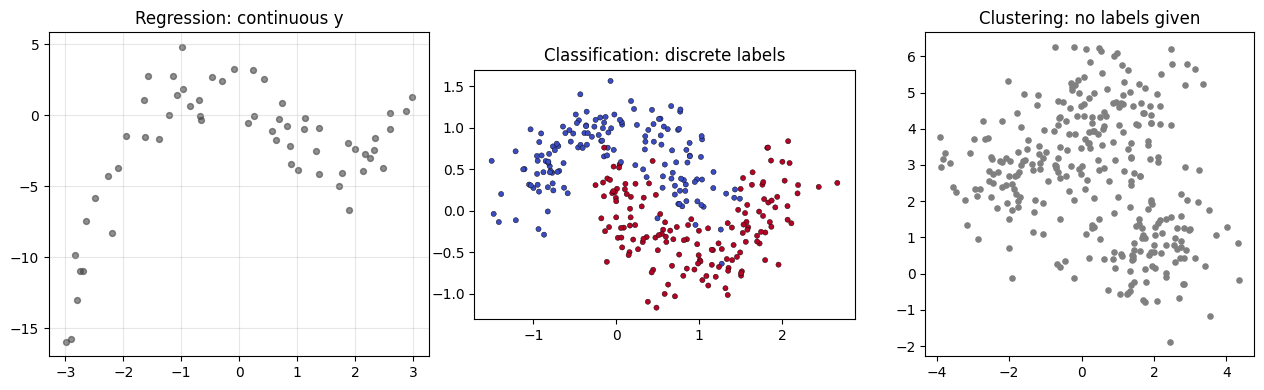

In [3]:
# Three pillars side by side.
x_reg, y_reg = datasets.make_polynomial_dataset(n=60, degree=3, noise=0.4, seed=0)
X_clf, y_clf = datasets.make_moons_dataset(n=300, noise=0.25, seed=0)
X_clu, _ = datasets.make_blobs_dataset(n=300, centers=3, cluster_std=1.0, seed=0)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
plotting.plot_regression_fit(x_reg, y_reg, ax=axes[0], title="Regression: continuous y")
axes[1].scatter(X_clf[:, 0], X_clf[:, 1], c=y_clf, cmap="coolwarm", s=14, edgecolors="k", linewidths=0.3)
axes[1].set_title("Classification: discrete labels")
axes[2].scatter(X_clu[:, 0], X_clu[:, 1], c="gray", s=14)
axes[2].set_title("Clustering: no labels given")
for ax in axes[1:]:
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 2. 汎化 — 訓練精度ではなくテスト精度

機械学習の目的は、訓練データを覚えることではなく、**まだ見ていないデータで当てる**(汎化)ことです。
そのため、データを **訓練用** と **テスト用** に分け、テスト側は学習に一切使いません。

下図は分類データを訓練(青)とテスト(赤▲)に分けた様子です。
モデルは青だけを見て学習し、赤で「初見の成績」を測ります。

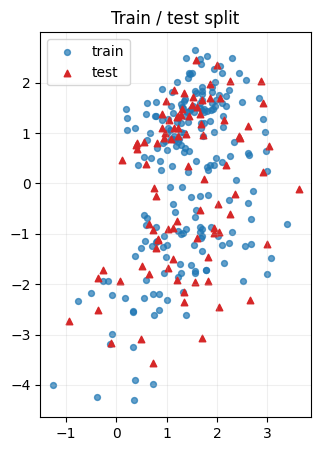

train: 210 samples, test: 90 samples


In [4]:
from sklearn.model_selection import train_test_split

X, y = datasets.make_classification_dataset(n=300, n_features=2, class_sep=1.3, seed=0)
idx = np.arange(len(X))
train_idx, test_idx = train_test_split(idx, test_size=0.3, random_state=0, stratify=y)

ax = plotting.plot_train_test_split(X, train_idx, test_idx)
ax.set_aspect("equal")
plt.show()

print(f"train: {len(train_idx)} samples, test: {len(test_idx)} samples")

## 3. 未学習・過学習・モデルの複雑さ

- **未学習 (underfitting)**: モデルが単純すぎてデータの形を捉えられない(訓練もテストも悪い)
- **過学習 (overfitting)**: モデルが複雑すぎて訓練データのノイズまで覚える(訓練は良いがテストが悪い)

1 次元回帰で、多項式の **次数**(=複雑さ)を変えて比べます。
真の関数は 3 次なので、次数 1 は未学習、次数 15 は過学習になるはずです。

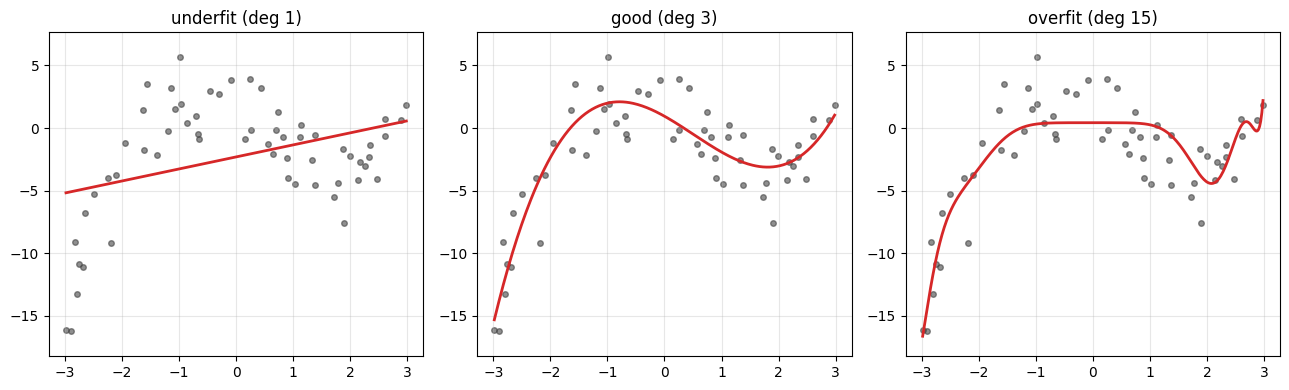

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

x, y = datasets.make_polynomial_dataset(n=60, degree=3, noise=0.5, seed=0)
grid = np.linspace(x.min(), x.max(), 300)[:, None]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, deg, name in zip(axes, [1, 3, 15], ["underfit (deg 1)", "good (deg 3)", "overfit (deg 15)"]):
    model = make_pipeline(PolynomialFeatures(deg), LinearRegression()).fit(x, y)
    ax.scatter(x, y, s=16, color="#444", alpha=0.6)
    ax.plot(grid, model.predict(grid), color="#d62728", lw=2)
    ax.set_ylim(y.min() - 2, y.max() + 2)
    ax.set_title(name)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### インタラクティブ: 複雑さ(次数)スライダー

下のスライダーで多項式の次数を動かすと、**訓練 RMSE は下がり続けるのにテスト RMSE は途中から上がる**
— これが過学習です。このスライダーは Plotly 製なので、静的 HTML でも動きます。

In [6]:
fig = plotting.plotly_model_complexity(x, y, degrees=range(1, 14))
fig.show()

## 4. バイアス-バリアンスのトレードオフ

- **バイアス**: モデルの想定が単純すぎて生じる系統誤差(未学習の原因)
- **バリアンス**: 訓練データの揺らぎに敏感すぎて生じる誤差(過学習の原因)

複雑さを上げるとバイアスは減るがバリアンスは増える。両者の和(汎化誤差)は **U 字** を描き、
その底が最良の複雑さです。決定木の深さを横軸に、交差検証スコアの **検証曲線** で確認します。

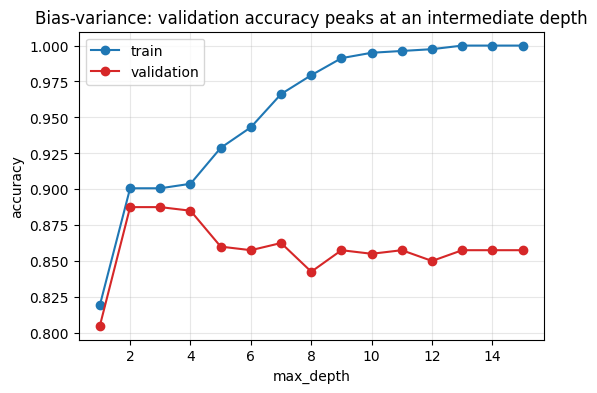

In [7]:
from sklearn.tree import DecisionTreeClassifier

X, y = datasets.make_moons_dataset(n=400, noise=0.3, seed=0)
ax = plotting.plot_validation_curve(
    DecisionTreeClassifier(random_state=0), X, y,
    param_name="max_depth", param_range=list(range(1, 16)), cv=5, scoring="accuracy",
)
ax.set_title("Bias-variance: validation accuracy peaks at an intermediate depth")
plt.show()

### バイアスとバリアンスを分解して見る

「複雑さ↑でバイアス↓・バリアンス↑」を数値で分解します。同じ真の関数からノイズだけ変えた訓練集合を
何百個も作り、各次数で学習 → テスト点での予測の **ばらつき(variance)** と **平均的なズレ(bias²)** を測ります。
両者の和(+既約ノイズ)が汎化誤差で、その U 字の底が最良の複雑さです。

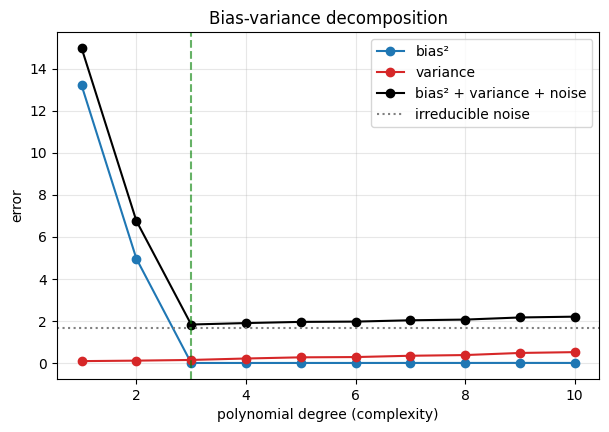

best degree by total error: 3


In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures


def true_fn(t):
    return 0.5 * t**3 - t**2 - 2 * t + 1   # same curve as make_polynomial_dataset


rng = np.random.default_rng(0)
x_train = np.sort(rng.uniform(-3, 3, 40))
x_test = np.linspace(-3, 3, 120)
f_test = true_fn(x_test)
noise_sd = 0.3 * true_fn(x_train).std()
degrees = list(range(1, 11))
R = 200

bias2, variance = [], []
for d in degrees:
    preds = np.zeros((R, len(x_test)))
    for r in range(R):
        y_train = true_fn(x_train) + noise_sd * rng.standard_normal(40)
        model = make_pipeline(PolynomialFeatures(d), LinearRegression()).fit(x_train[:, None], y_train)
        preds[r] = model.predict(x_test[:, None])
    bias2.append(float(np.mean((preds.mean(0) - f_test) ** 2)))
    variance.append(float(np.mean(preds.var(0))))
bias2, variance = np.array(bias2), np.array(variance)
total = bias2 + variance + noise_sd**2

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(degrees, bias2, "o-", label="bias²", color="#1f77b4")
ax.plot(degrees, variance, "o-", label="variance", color="#d62728")
ax.plot(degrees, total, "o-", label="bias² + variance + noise", color="black")
ax.axhline(noise_sd**2, ls=":", color="gray", label="irreducible noise")
ax.axvline(degrees[int(np.argmin(total))], ls="--", color="green", alpha=0.6)
ax.set_xlabel("polynomial degree (complexity)"); ax.set_ylabel("error")
ax.set_title("Bias-variance decomposition"); ax.legend(); ax.grid(alpha=0.3); plt.show()
print(f"best degree by total error: {degrees[int(np.argmin(total))]}")

## 5. 決定境界 — モデルが世界をどう区切るか

同じデータでも、モデルが引く **決定境界** はまるで違います。

- ロジスティック回帰: 直線(線形)。曲がれないので moons では未学習。
- 決定木: 軸に平行な階段状の境界。
- k 近傍法: なめらかだが局所的。

「どのモデルが正解」ではなく、**仮説の形が違う** ことを掴んでください。

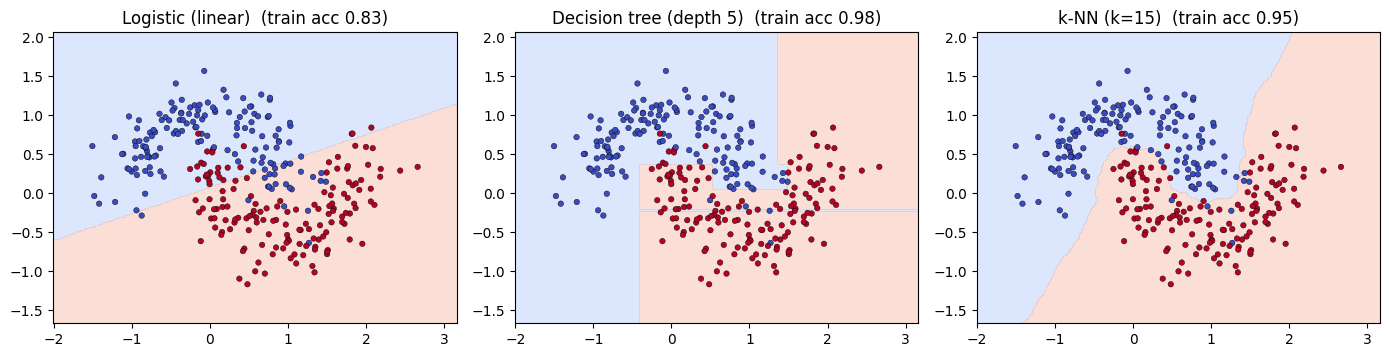

In [9]:
from sklearn.neighbors import KNeighborsClassifier

X, y = datasets.make_moons_dataset(n=300, noise=0.25, seed=0)
fitted = {
    "Logistic (linear)": models.get_logistic_regression().fit(X, y),
    "Decision tree (depth 5)": models.get_decision_tree(max_depth=5).fit(X, y),
    "k-NN (k=15)": KNeighborsClassifier(n_neighbors=15).fit(X, y),
}
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, (name, clf) in zip(axes, fitted.items()):
    plotting.plot_decision_boundary(clf.predict, X, y, ax=ax, steps=200,
                                    title=f"{name}  (train acc {clf.score(X, y):.2f})")
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 6. ML ワークフローの全体像

実務の機械学習は、モデルを選ぶ前後にやることがたくさんあります。本書はこの流れを章として辿ります。

1. **問題定式化** — 何を $x$、何を $y$ にするか(本章)
2. **前処理・特徴量** — 欠損・スケール・カテゴリ・**リーク防止**(02 章)
3. **モデル** — 線形(03)/ 木(05)/ SVM(06)/ 教師なし(07)
4. **評価・検証** — 指標選び・交差検証・閾値・較正(04 章)← 最重要
5. **時系列の検証** — 時間順を壊さない(08 章)
6. **解釈** — なぜその予測か(09 章)
7. **パイプライン化と運用** — 再現性・ドリフト監視(10 章)

> スローガン: **「多くのモデルを試すより、正しく評価することの方が重要」**(04 章で徹底)。

### インタラクティブ(JupyterLab のみ): 複雑さと過学習

ipywidgets 版です。k 近傍法の $k$ を小さくするほど境界が複雑になり、訓練精度は上がるのにテスト精度は下がります。
(静的 HTML では動きません。上の Plotly スライダーと合わせてご覧ください。)

In [10]:
# Requires a live Jupyter kernel.
X, y = datasets.make_moons_dataset(n=300, noise=0.3, seed=0)
widgets.model_complexity_explorer(X, y)

interactive(children=(IntSlider(value=15, description='k', max=60, min=1, step=2), Output()), _dom_classes=('w…

<function ml_textbook.widgets.model_complexity_explorer.<locals>.draw(k)>

## 7. まとめ

- 機械学習は **損失を最小化してデータに合う関数を選ぶ最適化**。$y$ の種類で回帰/分類/(教師なし)が決まる。
- 目的は訓練精度ではなく **汎化**。だからデータを訓練/テストに分け、テストは学習に使わない。
- 単純すぎれば **未学習**、複雑すぎれば **過学習**。最良は **バイアスとバリアンスの均衡点**。
- モデルごとに **決定境界の形(仮説)** が違う。万能のモデルは無い(No Free Lunch)。
- モデル選びの前後に前処理・評価・検証・解釈・運用がある。本書はこの全工程を扱う。

## 8. Exercises

1. `make_classification_dataset` の `class_sep` を 0.5 / 1.5 / 3.0 と変え、線形モデルのテスト精度がどう動くか調べよ。
2. 多項式回帰の次数スライダーで、ノイズ(`noise`)を大きくすると「過学習が始まる次数」がどう変わるか観察せよ。
3. 決定木の `max_depth` の検証曲線で、データ点数 `n` を増やすと U 字の底がどちらに動くか確かめよ。
4. moons の `noise` を 0.1 と 0.4 にして、3 モデルの決定境界の違いがどう変化するか比較せよ。
5. (発展)クラスタリングの `make_blobs_dataset` で `centers` を 3 にしたまま k-means の k を 2/4 にすると何が起きるか予想し、07 章で確かめよ。

## 9. Common Mistakes

- **訓練精度で良し悪しを判断する。** 訓練精度は複雑にすれば 1.0 にできる。必ずテスト/交差検証で測る(04 章)。
- **テストデータを前処理や特徴量選択に使う。** これは **リーク**。テストは最後まで触らない(02・04 章)。
- **「複雑なモデル＝良いモデル」と思い込む。** 多くの実務問題では、正しく検証した単純なモデルが勝つ。
- **乱数 seed を固定しない。** 比較実験が再現しなくなる。本書は一貫して seed を固定している。

## 10. Advanced Notes

**No Free Lunch 定理。** あらゆる問題で最良という単一のアルゴリズムは存在しない。
モデルの「仮説の形」(帰納バイアス)がデータの構造に合っているかが性能を決める。
だからこそ、線形・木・カーネルといった **異なる仮説** を道具箱として持ち、評価で選ぶ。

**汎化誤差の分解(回帰)。** 期待二乗誤差は近似的に
$\mathbb{E}[(y-\hat f)^2] = \underbrace{(\text{bias})^2}_{\text{単純さ}} + \underbrace{\text{variance}}_{\text{敏感さ}} + \underbrace{\sigma^2}_{\text{既約ノイズ}}$
と分解できる。$\sigma^2$ はどんなモデルでも消せない下限で、ここを目指して複雑さを調整する。